# Member 1 — Data Validation and Exploratory Data Analysis

**Project:** MAST30034 Project 2 — Buy Now, Pay Later Merchant Ranking  
**Scope:** Sprint 1 / Member 1 responsibilities

This notebook:

1. inventories the supplied datasets and validates their schemas;
2. checks missing values and duplicate primary keys;
3. checks the core relationships between consumers, users, merchants and transactions;
4. explores transaction-value, merchant-category and time-series distributions;
5. records data-quality issues without deleting or changing any observations.

Fraud probability files are catalogued but excluded from the analysis because fraud-risk modelling belongs to Member 3. No ABS or other external data is required for this notebook.

## 1. Setup

Required packages: `duckdb`, `pandas`, `numpy`, `matplotlib`, and `seaborn`.

The notebook looks for a `tables` folder in the current/project directory. A different location can be supplied with the `PROJECT2_DATA_ROOT` environment variable.

In [1]:
from pathlib import Path
import os
import re
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid", context="notebook")


def find_data_root() -> Path:
    candidates = []
    configured = os.environ.get("PROJECT2_DATA_ROOT")
    if configured:
        candidates.append(Path(configured))
    candidates.extend([
        Path.cwd() / "tables",
        Path.cwd().parent / "tables",
        Path.home() / "OneDrive" / "Desktop" / "ads project 2" / "tables",
        Path.home() / "Desktop" / "ads project 2" / "tables",
    ])
    for candidate in candidates:
        if candidate.exists() and (candidate / "tbl_merchants.parquet").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the supplied tables folder. Set PROJECT2_DATA_ROOT to its path."
    )


DATA_ROOT = find_data_root()
ARTIFACT_DIR = Path.cwd() / "member1_eda_outputs"
FIGURE_DIR = ARTIFACT_DIR / "figures"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def sql_path(path: Path) -> str:
    return path.as_posix().replace("'", "''")


def quote_identifier(name: str) -> str:
    return '"' + name.replace('"', '""') + '"'


con = duckdb.connect()
con.execute("PRAGMA threads=4")

sources = {
    "tbl_consumer": f"read_csv_auto('{sql_path(DATA_ROOT / 'tbl_consumer.csv')}', header=true)",
    "consumer_user_details": f"read_parquet('{sql_path(DATA_ROOT / 'consumer_user_details.parquet')}')",
    "tbl_merchants": f"read_parquet('{sql_path(DATA_ROOT / 'tbl_merchants.parquet')}')",
    "consumer_fraud_probability": f"read_csv_auto('{sql_path(DATA_ROOT / 'consumer_fraud_probability.csv')}', header=true)",
    "merchant_fraud_probability": f"read_csv_auto('{sql_path(DATA_ROOT / 'merchant_fraud_probability.csv')}', header=true)",
    "transactions": (
        f"read_parquet('{sql_path(DATA_ROOT)}/transactions_*/order_datetime=*/part-*.parquet', "
        "hive_partitioning=true, union_by_name=true)"
    ),
}

for view_name, source in sources.items():
    con.execute(f"CREATE OR REPLACE VIEW {view_name} AS SELECT * FROM {source}")

CORE_TABLES = ["tbl_consumer", "consumer_user_details", "tbl_merchants", "transactions"]
FRAUD_TABLES = ["consumer_fraud_probability", "merchant_fraud_probability"]

print(f"Data root: {DATA_ROOT}")
print(f"Analysis outputs: {ARTIFACT_DIR}")

Data root: C:\Users\十五\Documents\Codex\2026-09-03\https-chatgpt-com-share-6a98fa9e-e718\work\project2_data\tables
Analysis outputs: C:\Users\十五\Documents\Codex\2026-09-03\https-chatgpt-com-share-6a98fa9e-e718\outputs\member1_eda\member1_eda_outputs


## 2. File inventory, shapes and schemas

In [2]:
partition_rows = []
for folder in sorted(DATA_ROOT.glob("transactions_*_snapshot")):
    files = sorted(folder.glob("order_datetime=*/part-*.parquet"))
    dates = [f.parent.name.split("=", 1)[1] for f in files]
    partition_rows.append({
        "dataset": folder.name,
        "parquet_files": len(files),
        "first_partition_date": min(dates) if dates else None,
        "last_partition_date": max(dates) if dates else None,
        "size_mb": round(sum(f.stat().st_size for f in files) / 1024**2, 1),
    })

file_inventory = pd.DataFrame([
    {"dataset": "tbl_consumer.csv", "files": 1, "size_mb": round((DATA_ROOT / "tbl_consumer.csv").stat().st_size / 1024**2, 1)},
    {"dataset": "consumer_user_details.parquet", "files": 1, "size_mb": round((DATA_ROOT / "consumer_user_details.parquet").stat().st_size / 1024**2, 1)},
    {"dataset": "tbl_merchants.parquet", "files": 1, "size_mb": round((DATA_ROOT / "tbl_merchants.parquet").stat().st_size / 1024**2, 1)},
    {"dataset": "consumer_fraud_probability.csv", "files": 1, "size_mb": round((DATA_ROOT / "consumer_fraud_probability.csv").stat().st_size / 1024**2, 1)},
    {"dataset": "merchant_fraud_probability.csv", "files": 1, "size_mb": round((DATA_ROOT / "merchant_fraud_probability.csv").stat().st_size / 1024**2, 1)},
])
display(file_inventory)
display(pd.DataFrame(partition_rows))

shape_rows = []
schema_parts = []
for table in [*CORE_TABLES, *FRAUD_TABLES]:
    row_count = con.execute(f"SELECT count(*) FROM {table}").fetchone()[0]
    schema = con.execute(f"DESCRIBE SELECT * FROM {table}").df()
    shape_rows.append({"table": table, "rows": row_count, "columns": len(schema), "scope": "Member 1 core" if table in CORE_TABLES else "Member 3 / catalogued only"})
    schema.insert(0, "table", table)
    schema_parts.append(schema[["table", "column_name", "column_type", "null"]])

shape_summary = pd.DataFrame(shape_rows)
schema_summary = pd.concat(schema_parts, ignore_index=True)
shape_summary.to_csv(ARTIFACT_DIR / "table_shapes.csv", index=False)
schema_summary.to_csv(ARTIFACT_DIR / "schema_summary.csv", index=False)

display(shape_summary)
display(schema_summary)

,dataset,files,size_mb
0,tbl_consumer.csv,1,28.8
1,consumer_user_details.parquet,1,4.8
2,tbl_merchants.parquet,1,0.1
3,consumer_fraud_probability.csv,1,1.2
4,merchant_fraud_probability.csv,1,0.0


,dataset,parquet_files,first_partition_date,last_partition_date,size_mb
0,transactions_20210228_20210827_snapshot,181,2021-02-28,2021-08-27,176.8
1,transactions_20210828_20220227_snapshot,184,2021-08-28,2022-02-27,217.3
2,transactions_20220228_20220828_snapshot,241,2022-02-28,2022-10-26,291.4


,table,rows,columns,scope
0,tbl_consumer,499999,6,Member 1 core
1,consumer_user_details,499999,2,Member 1 core
2,tbl_merchants,4026,3,Member 1 core
3,transactions,14195505,5,Member 1 core
4,consumer_fraud_probability,34864,3,Member 3 / catalogued only
5,merchant_fraud_probability,114,3,Member 3 / catalogued only


,table,column_name,column_type,null
0,tbl_consumer,name,VARCHAR,YES
1,tbl_consumer,address,VARCHAR,YES
2,tbl_consumer,state,VARCHAR,YES
3,tbl_consumer,postcode,BIGINT,YES
4,tbl_consumer,gender,VARCHAR,YES
5,tbl_consumer,consumer_id,BIGINT,YES
6,consumer_user_details,user_id,BIGINT,YES
7,consumer_user_details,consumer_id,BIGINT,YES
8,tbl_merchants,name,VARCHAR,YES
9,tbl_merchants,tags,VARCHAR,YES


### Sample records

Only small samples are displayed. Full transaction data remains in Parquet and is queried directly with DuckDB, so the notebook does not attempt to load 14+ million rows into memory.

In [3]:
for table in CORE_TABLES:
    display(Markdown(f"**{table}**"))
    display(con.execute(f"SELECT * FROM {table} LIMIT 5").df())

**tbl_consumer**

,name,address,state,postcode,gender,consumer_id
0,Yolanda Williams,413 Haney Gardens Apt. 742,WA,6935,Female,1195503
1,Mary Smith,3764 Amber Oval,NSW,2782,Female,179208
2,Jill Jones MD,40693 Henry Greens,NT,862,Female,1194530
3,Lindsay Jimenez,00653 Davenport Crossroad,NSW,2780,Female,154128
4,Rebecca Blanchard,9271 Michael Manors Suite 651,WA,6355,Female,712975


**consumer_user_details**

,user_id,consumer_id
0,1,1195503
1,2,179208
2,3,1194530
3,4,154128
4,5,712975


**tbl_merchants**

,name,tags,merchant_abn
0,Felis Limited,"((furniture, home furnishings and equipment shops, and manufacturers, except appliances), (e), (...",10023283211
1,Arcu Ac Orci Corporation,"([cable, satellite, and otHer pay television and radio services], [b], [take rate: 4.22])",10142254217
2,Nunc Sed Company,"([jewelry, watch, clock, and silverware shops], [b], [take rate: 4.40])",10165489824
3,Ultricies Dignissim Lacus Foundation,"([wAtch, clock, and jewelry repair shops], [b], [take rate: 3.29])",10187291046
4,Enim Condimentum PC,"([music shops - musical instruments, pianos, and sheet music], [a], [take rate: 6.33])",10192359162


**transactions**

,user_id,merchant_abn,dollar_value,order_id,order_datetime
0,1,28000487688,133.226894,0c37b3f7-c7f1-48cb-bcc7-0a58e76608ea,2021-02-28
1,18485,62191208634,79.131400,9e18b913-0465-4fd4-92fd-66d15e65d93c,2021-02-28
2,1,83690644458,30.441348,40a2ff69-ea34-4657-8429-df7ca957d6a1,2021-02-28
3,18488,39649557865,962.813341,f4c1a5ae-5b76-40d0-ae0f-cb9730ac325a,2021-02-28
4,2,80779820715,48.123977,cd09bdd6-f56d-489f-81ea-440f4bda933c,2021-02-28


## 3. Missing values and primary-key checks

In [4]:
missing_rows = []
for table in CORE_TABLES:
    columns = con.execute(f"DESCRIBE SELECT * FROM {table}").df()["column_name"].tolist()
    expressions = [
        f"SUM(CASE WHEN {quote_identifier(col)} IS NULL THEN 1 ELSE 0 END) AS {quote_identifier(col)}"
        for col in columns
    ]
    counts = con.execute(f"SELECT {', '.join(expressions)} FROM {table}").fetchone()
    total = con.execute(f"SELECT count(*) FROM {table}").fetchone()[0]
    for col, count in zip(columns, counts):
        missing_rows.append({
            "table": table,
            "column": col,
            "missing_count": int(count),
            "missing_rate": (count / total) if total else np.nan,
        })

missing_summary = pd.DataFrame(missing_rows)
missing_summary.to_csv(ARTIFACT_DIR / "missing_value_summary.csv", index=False)
display(missing_summary)

primary_keys = {
    "tbl_consumer": "consumer_id",
    "consumer_user_details": "user_id",
    "tbl_merchants": "merchant_abn",
    "transactions": "order_id",
}

duplicate_rows = []
for table, key in primary_keys.items():
    qkey = quote_identifier(key)
    result = con.execute(f"""
        SELECT
            count(*) AS row_count,
            count(*) FILTER (WHERE {qkey} IS NULL) AS null_key_rows,
            count(DISTINCT {qkey}) FILTER (WHERE {qkey} IS NOT NULL) AS distinct_non_null_keys
        FROM {table}
    """).fetchone()
    row_count, null_key_rows, distinct_keys = map(int, result)
    duplicate_rows.append({
        "table": table,
        "primary_key": key,
        "row_count": row_count,
        "null_key_rows": null_key_rows,
        "distinct_non_null_keys": distinct_keys,
        "duplicate_key_rows_beyond_first": row_count - null_key_rows - distinct_keys,
    })

duplicate_summary = pd.DataFrame(duplicate_rows)
duplicate_summary.to_csv(ARTIFACT_DIR / "duplicate_key_summary.csv", index=False)
display(duplicate_summary)

if missing_summary["missing_count"].sum() == 0:
    display(Markdown("All four core tables have **zero SQL `NULL` values**, so a missing-value chart would add no information."))
if duplicate_summary["duplicate_key_rows_beyond_first"].sum() == 0:
    display(Markdown("All nominated primary keys are non-null and unique, including `transactions.order_id`."))

,table,column,missing_count,missing_rate
0,tbl_consumer,name,0,0.0
1,tbl_consumer,address,0,0.0
2,tbl_consumer,state,0,0.0
3,tbl_consumer,postcode,0,0.0
4,tbl_consumer,gender,0,0.0
5,tbl_consumer,consumer_id,0,0.0
6,consumer_user_details,user_id,0,0.0
7,consumer_user_details,consumer_id,0,0.0
8,tbl_merchants,name,0,0.0
9,tbl_merchants,tags,0,0.0


,table,primary_key,row_count,null_key_rows,distinct_non_null_keys,duplicate_key_rows_beyond_first
0,tbl_consumer,consumer_id,499999,0,499999,0
1,consumer_user_details,user_id,499999,0,499999,0
2,tbl_merchants,merchant_abn,4026,0,4026,0
3,transactions,order_id,14195505,0,14195505,0


All four core tables have **zero SQL `NULL` values**, so a missing-value chart would add no information.

All nominated primary keys are non-null and unique, including `transactions.order_id`.

## 4. Relationship and coverage checks

In [5]:
transaction_links = con.execute("""
    SELECT
        count(*) AS transaction_rows,
        count(*) FILTER (WHERE u.user_id IS NOT NULL) AS rows_with_known_user,
        count(*) FILTER (WHERE m.merchant_abn IS NOT NULL) AS rows_with_known_merchant,
        count(*) FILTER (WHERE u.user_id IS NULL) AS rows_with_unknown_user,
        count(*) FILTER (WHERE m.merchant_abn IS NULL) AS rows_with_unknown_merchant,
        count(DISTINCT t.user_id) FILTER (WHERE u.user_id IS NULL) AS distinct_unknown_user_ids,
        count(DISTINCT t.merchant_abn) FILTER (WHERE m.merchant_abn IS NULL) AS distinct_unknown_merchant_abns
    FROM transactions t
    LEFT JOIN consumer_user_details u USING (user_id)
    LEFT JOIN tbl_merchants m USING (merchant_abn)
""").df()

mapping_links = con.execute("""
    SELECT
        count(*) AS mapping_rows,
        count(*) FILTER (WHERE c.consumer_id IS NOT NULL) AS matched_consumer_rows,
        count(*) FILTER (WHERE c.consumer_id IS NULL) AS unmatched_consumer_rows
    FROM consumer_user_details u
    LEFT JOIN tbl_consumer c USING (consumer_id)
""").df()

relationship_summary = pd.concat([
    transaction_links.assign(check="transactions_to_users_and_merchants"),
    mapping_links.assign(check="user_mapping_to_consumers"),
], ignore_index=True, sort=False)
relationship_summary.to_csv(ARTIFACT_DIR / "relationship_summary.csv", index=False)
display(transaction_links)
display(mapping_links)

unknown_merchant_rate = transaction_links.loc[0, "rows_with_unknown_merchant"] / transaction_links.loc[0, "transaction_rows"]
display(Markdown(
    f"All transaction users match the user mapping. However, **{transaction_links.loc[0, 'rows_with_unknown_merchant']:,}** "
    f"transactions (**{unknown_merchant_rate:.2%}**) refer to **{transaction_links.loc[0, 'distinct_unknown_merchant_abns']:,}** "
    "merchant ABNs that are absent from the supplied merchant master. These rows should be retained and flagged for follow-up."
))

,transaction_rows,rows_with_known_user,rows_with_known_merchant,rows_with_unknown_user,rows_with_unknown_merchant,distinct_unknown_user_ids,distinct_unknown_merchant_abns
0,14195505,14195505,13614675,0,580830,0,396


,mapping_rows,matched_consumer_rows,unmatched_consumer_rows
0,499999,499999,0


All transaction users match the user mapping. However, **580,830** transactions (**4.09%**) refer to **396** merchant ABNs that are absent from the supplied merchant master. These rows should be retained and flagged for follow-up.

## 5. Transaction-value distribution

,value
transaction_count,1.419550e+07
minimum,9.756658e-08
q1,2.612958e+01
median,6.223040e+01
mean,1.662290e+02
q3,1.504517e+02
p95,5.905171e+02
p99,1.619273e+03
maximum,1.051939e+05
standard_deviation,5.178506e+02


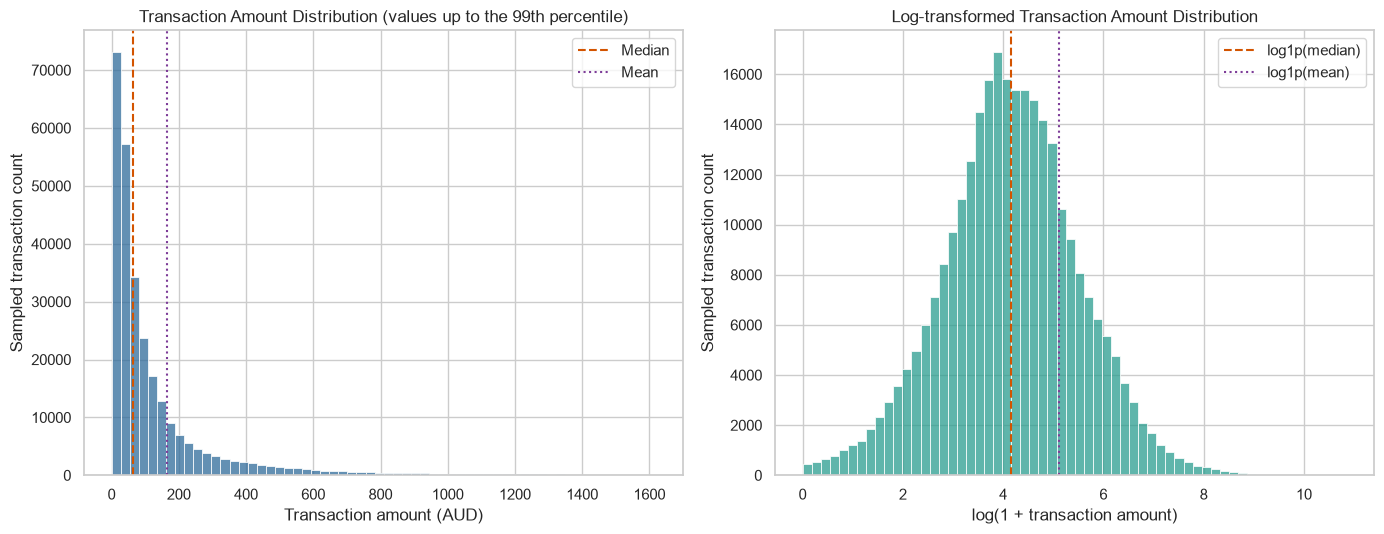

The amount distribution is right-skewed: the mean is **$166.23**, compared with a median of **$62.23**. The 99th percentile is **$1,619.27**, while the maximum is **$105,193.89**. The left panel is capped at the 99th percentile for readability, while the right panel applies log1p to the full non-negative plotting sample. The original dollar_value field is retained and no observations are removed from the underlying data.

In [6]:
transaction_stats = con.execute("""
    SELECT
        count(*) AS transaction_count,
        min(dollar_value) AS minimum,
        quantile_cont(dollar_value, 0.25) AS q1,
        quantile_cont(dollar_value, 0.50) AS median,
        avg(dollar_value) AS mean,
        quantile_cont(dollar_value, 0.75) AS q3,
        quantile_cont(dollar_value, 0.95) AS p95,
        quantile_cont(dollar_value, 0.99) AS p99,
        max(dollar_value) AS maximum,
        stddev_samp(dollar_value) AS standard_deviation,
        count(*) FILTER (WHERE dollar_value <= 0) AS non_positive_count
    FROM transactions
""").df()

q1 = float(transaction_stats.loc[0, "q1"])
q3 = float(transaction_stats.loc[0, "q3"])
p99 = float(transaction_stats.loc[0, "p99"])
iqr_upper = q3 + 1.5 * (q3 - q1)
outlier_counts = con.execute("""
    SELECT
        count(*) FILTER (WHERE dollar_value > ?) AS above_iqr_upper_count,
        count(*) FILTER (WHERE dollar_value > ?) AS above_p99_count
    FROM transactions
""", [iqr_upper, p99]).df()

transaction_stats["iqr_upper_fence"] = iqr_upper
transaction_stats["above_iqr_upper_count"] = int(outlier_counts.loc[0, "above_iqr_upper_count"])
transaction_stats["above_p99_count"] = int(outlier_counts.loc[0, "above_p99_count"])
transaction_stats.to_csv(ARTIFACT_DIR / "transaction_value_summary.csv", index=False)
display(transaction_stats.T.rename(columns={0: "value"}))

# A deterministic ~2% hash sample is used for plotting only. All summary statistics above use the full dataset.
amount_sample = con.execute("""
    SELECT dollar_value
    FROM transactions
    WHERE hash(order_id) % 100 < 2
""").df()

# Keep the raw amount unchanged. The log1p feature is derived only for visualisation
# and can also be considered by downstream models that are sensitive to skewness.
raw_amount_sample = amount_sample.loc[amount_sample["dollar_value"] <= p99].copy()
log_amount_sample = amount_sample.loc[amount_sample["dollar_value"] >= 0].copy()
log_amount_sample["log1p_dollar_value"] = np.log1p(log_amount_sample["dollar_value"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.histplot(data=raw_amount_sample, x="dollar_value", bins=60, color="#2F6B9A", ax=axes[0])
axes[0].set(
    title="Transaction Amount Distribution (values up to the 99th percentile)",
    xlabel="Transaction amount (AUD)",
    ylabel="Sampled transaction count",
)
axes[0].axvline(float(transaction_stats.loc[0, "median"]), color="#D35400", linestyle="--", label="Median")
axes[0].axvline(float(transaction_stats.loc[0, "mean"]), color="#7D3C98", linestyle=":", label="Mean")
axes[0].legend()

sns.histplot(data=log_amount_sample, x="log1p_dollar_value", bins=60, color="#2A9D8F", ax=axes[1])
axes[1].set(
    title="Log-transformed Transaction Amount Distribution",
    xlabel="log(1 + transaction amount)",
    ylabel="Sampled transaction count",
)
axes[1].axvline(np.log1p(float(transaction_stats.loc[0, "median"])), color="#D35400", linestyle="--", label="log1p(median)")
axes[1].axvline(np.log1p(float(transaction_stats.loc[0, "mean"])), color="#7D3C98", linestyle=":", label="log1p(mean)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_transaction_amount_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

display(Markdown(
    f"The amount distribution is right-skewed: the mean is **${transaction_stats.loc[0, 'mean']:,.2f}**, "
    f"compared with a median of **${transaction_stats.loc[0, 'median']:,.2f}**. "
    f"The 99th percentile is **${p99:,.2f}**, while the maximum is **${transaction_stats.loc[0, 'maximum']:,.2f}**. "
    "The left panel is capped at the 99th percentile for readability, while the right panel applies log1p to the "
    "full non-negative plotting sample. The original dollar_value field is retained and no observations are removed "
    "from the underlying data."
))

## 6. Merchant categories

Merchant-tag parse success: **100.00%**

,merchant_segment,merchant_count
0,a,1602
1,b,1351
2,c,922
3,d,98
4,e,53


,merchant_category,merchant_count
0,"digital goods: books, movies, music",195
1,artist supply and craft shops,193
2,"computer programming , data processing, and integrated systems design services",191
3,shoe shops,185
4,"furniture, home furnishings and equipment shops, and manufacturers, except appliances",182
5,"gift, card, novelty, and souvenir shops",182
6,"computers, computer peripheral equipment, and software",181
7,"florists supplies, nursery stock, and flowers",180
8,tent and awning shops,178
9,"cable, satellite, and other pay television and radio services",175


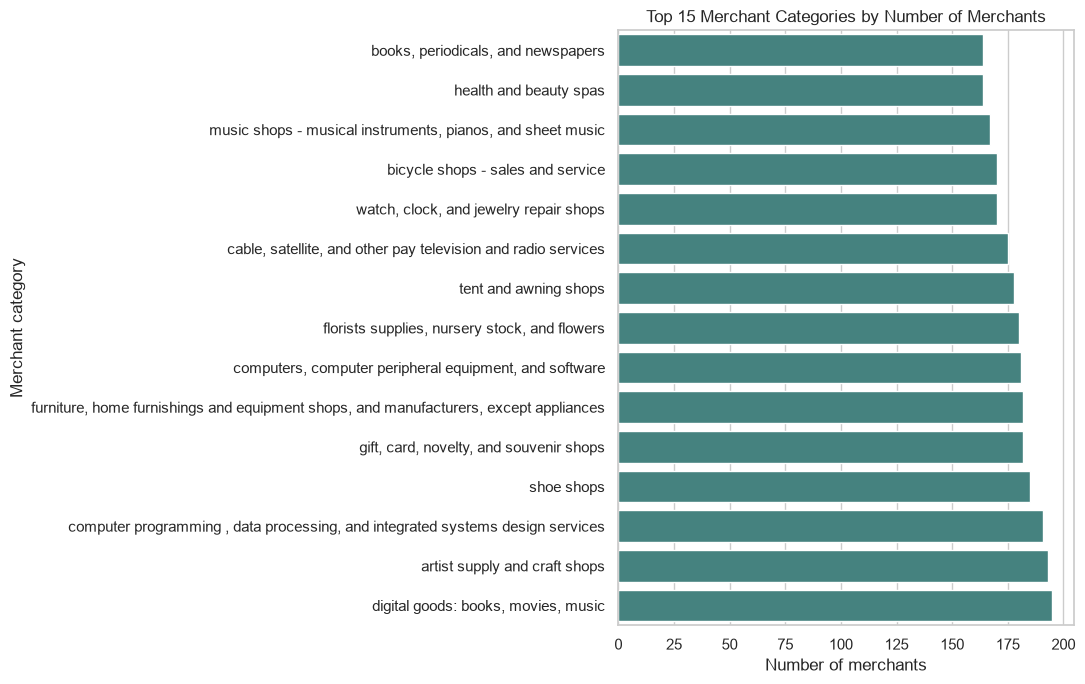

All merchant tags were parsed successfully into **25** category labels. The largest category is **digital goods: books, movies, music** with **195** merchants. The distribution is uneven, so later segmentation should not rely on equal category sizes. Capitalisation was normalised for this count, while the raw `tags` field remains unchanged.

In [7]:
merchants = con.execute("SELECT * FROM tbl_merchants").df()

tag_pattern = re.compile(
    r"^[\(\[]\s*[\(\[](?P<category>.*?)\s*[\)\]]\s*,\s*"
    r"[\(\[](?P<segment>[a-e])\s*[\)\]]\s*,\s*"
    r"[\(\[]take\s+rate:\s*(?P<take_rate>\d+(?:\.\d+)?)\s*[\)\]]\s*[\)\]]$",
    re.IGNORECASE,
)


def parse_tags(value):
    if pd.isna(value):
        return pd.Series({"merchant_category": None, "merchant_segment": None, "take_rate": np.nan})
    match = tag_pattern.match(str(value).strip())
    if not match:
        return pd.Series({"merchant_category": None, "merchant_segment": None, "take_rate": np.nan})
    category = re.sub(r"\s+", " ", match.group("category")).strip().lower()
    return pd.Series({
        "merchant_category": category,
        "merchant_segment": match.group("segment").lower(),
        "take_rate": float(match.group("take_rate")),
    })


parsed_tags = merchants["tags"].apply(parse_tags)
merchants_parsed = pd.concat([merchants, parsed_tags], axis=1)
parse_rate = merchants_parsed["merchant_category"].notna().mean()

category_counts = (
    merchants_parsed["merchant_category"]
    .fillna("unparsed / missing")
    .value_counts()
    .rename_axis("merchant_category")
    .reset_index(name="merchant_count")
)
segment_counts = (
    merchants_parsed["merchant_segment"]
    .fillna("unparsed / missing")
    .value_counts()
    .rename_axis("merchant_segment")
    .reset_index(name="merchant_count")
)
category_counts.to_csv(ARTIFACT_DIR / "merchant_category_counts.csv", index=False)
segment_counts.to_csv(ARTIFACT_DIR / "merchant_segment_counts.csv", index=False)

display(Markdown(f"Merchant-tag parse success: **{parse_rate:.2%}**"))
display(segment_counts)
display(category_counts.head(15))

top_categories = category_counts.head(15).sort_values("merchant_count")
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=top_categories, x="merchant_count", y="merchant_category", color="#3B8C88", ax=ax)
ax.set(
    title="Top 15 Merchant Categories by Number of Merchants",
    xlabel="Number of merchants",
    ylabel="Merchant category",
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_merchant_category_counts.png", dpi=180, bbox_inches="tight")
plt.show()

display(Markdown(
    f"All merchant tags were parsed successfully into **{category_counts['merchant_category'].nunique():,}** category labels. "
    f"The largest category is **{category_counts.loc[0, 'merchant_category']}** with **{category_counts.loc[0, 'merchant_count']:,}** merchants. "
    "The distribution is uneven, so later segmentation should not rely on equal category sizes. "
    "Capitalisation was normalised for this count, while the raw `tags` field remains unchanged."
))

## 7. Transaction trend over time

,first_transaction_date,last_transaction_date,observed_dates,expected_calendar_dates,missing_calendar_dates,peak_transaction_date,peak_daily_transaction_count,first_28_day_average_count,last_28_day_average_count,first_to_last_28_day_change
0,2021-02-28,2022-10-26,606,606,0,2021-11-26,61237,17601.214286,28347.857143,0.610563


,transaction_date,transaction_count,total_amount,active_users,active_merchants
0,2021-02-01,17107,2.784089e+06,12259,2019
1,2021-03-01,546333,9.108158e+07,14003,2175
2,2021-04-01,560680,9.311185e+07,14223,2182
3,2021-05-01,636666,1.060009e+08,14654,2215
4,2021-06-01,627148,1.036115e+08,14551,2207
5,2021-07-01,655279,1.096182e+08,14918,2251
6,2021-08-01,688822,1.144559e+08,16009,2310
7,2021-09-01,678524,1.128726e+08,15304,2265
8,2021-10-01,729619,1.212318e+08,15704,2302
9,2021-11-01,991226,1.648050e+08,22230,2878


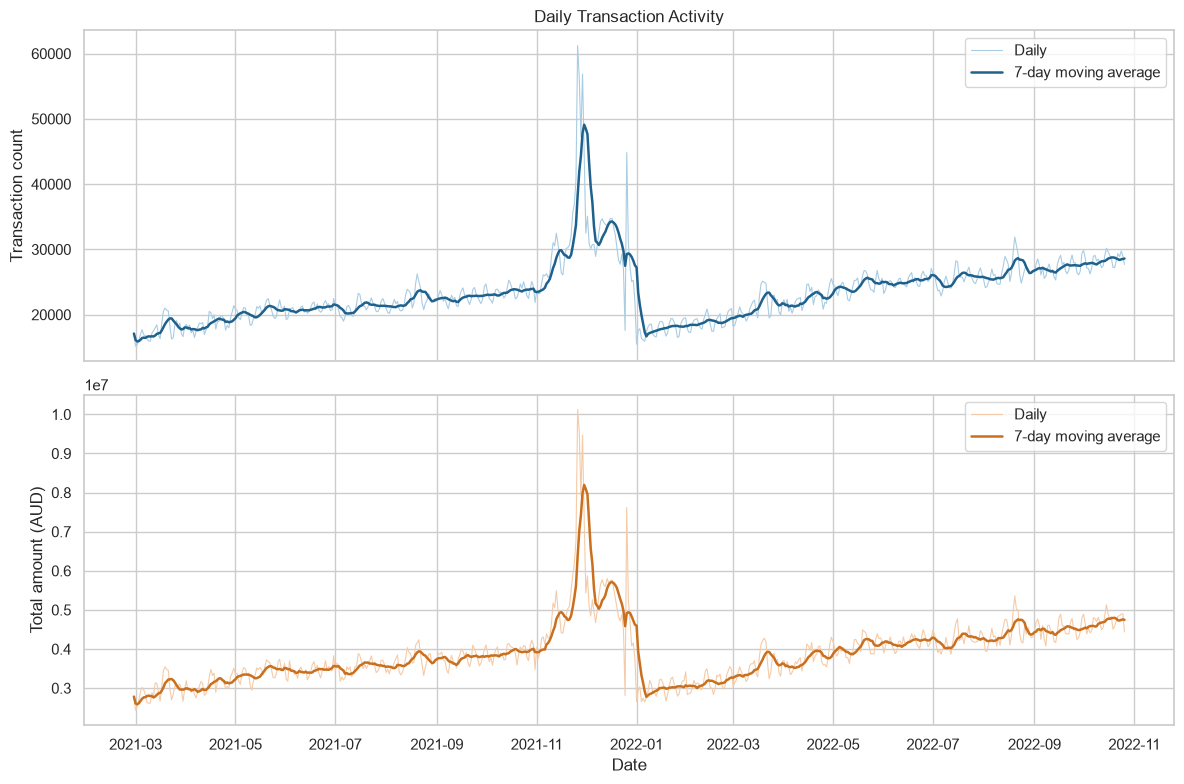

Transactions cover **2021-02-28 to 2022-10-26**. There are **0 missing calendar dates** within that range. Daily volume peaked at **61,237 transactions on 2021-11-26**. The average daily count in the last 28 days is **+61.1%** versus the first 28 days. The late-2021 spike and sharp subsequent level change should be investigated rather than assumed to be normal seasonality.

In [8]:
daily_transactions = con.execute("""
    SELECT
        order_datetime AS transaction_date,
        count(*) AS transaction_count,
        sum(dollar_value) AS total_amount,
        avg(dollar_value) AS average_amount,
        count(DISTINCT user_id) AS active_users,
        count(DISTINCT merchant_abn) AS active_merchants
    FROM transactions
    GROUP BY order_datetime
    ORDER BY order_datetime
""").df()
daily_transactions["transaction_date"] = pd.to_datetime(daily_transactions["transaction_date"])
daily_transactions["transaction_count_7d_ma"] = daily_transactions["transaction_count"].rolling(7, min_periods=1).mean()
daily_transactions["total_amount_7d_ma"] = daily_transactions["total_amount"].rolling(7, min_periods=1).mean()

monthly_transactions = (
    daily_transactions
    .set_index("transaction_date")
    .resample("MS")
    .agg({"transaction_count": "sum", "total_amount": "sum", "active_users": "max", "active_merchants": "max"})
    .reset_index()
)

daily_transactions.to_csv(ARTIFACT_DIR / "daily_transaction_trend.csv", index=False)
monthly_transactions.to_csv(ARTIFACT_DIR / "monthly_transaction_trend.csv", index=False)

expected_days = pd.date_range(daily_transactions["transaction_date"].min(), daily_transactions["transaction_date"].max(), freq="D")
missing_dates = expected_days.difference(daily_transactions["transaction_date"])
peak_count_row = daily_transactions.loc[daily_transactions["transaction_count"].idxmax()]
first_28_mean = daily_transactions.head(28)["transaction_count"].mean()
last_28_mean = daily_transactions.tail(28)["transaction_count"].mean()
volume_change = last_28_mean / first_28_mean - 1

time_summary = pd.DataFrame([{
    "first_transaction_date": daily_transactions["transaction_date"].min().date(),
    "last_transaction_date": daily_transactions["transaction_date"].max().date(),
    "observed_dates": len(daily_transactions),
    "expected_calendar_dates": len(expected_days),
    "missing_calendar_dates": len(missing_dates),
    "peak_transaction_date": peak_count_row["transaction_date"].date(),
    "peak_daily_transaction_count": int(peak_count_row["transaction_count"]),
    "first_28_day_average_count": first_28_mean,
    "last_28_day_average_count": last_28_mean,
    "first_to_last_28_day_change": volume_change,
}])
time_summary.to_csv(ARTIFACT_DIR / "time_coverage_summary.csv", index=False)
display(time_summary)
display(monthly_transactions)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily_transactions["transaction_date"], daily_transactions["transaction_count"], color="#A9CCE3", linewidth=0.8, label="Daily")
axes[0].plot(daily_transactions["transaction_date"], daily_transactions["transaction_count_7d_ma"], color="#1F618D", linewidth=1.8, label="7-day moving average")
axes[0].set(title="Daily Transaction Activity", ylabel="Transaction count")
axes[0].legend()

axes[1].plot(daily_transactions["transaction_date"], daily_transactions["total_amount"], color="#F5CBA7", linewidth=0.8, label="Daily")
axes[1].plot(daily_transactions["transaction_date"], daily_transactions["total_amount_7d_ma"], color="#CA6F1E", linewidth=1.8, label="7-day moving average")
axes[1].set(xlabel="Date", ylabel="Total amount (AUD)")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_daily_transaction_trends.png", dpi=180, bbox_inches="tight")
plt.show()

display(Markdown(
    f"Transactions cover **{time_summary.loc[0, 'first_transaction_date']} to {time_summary.loc[0, 'last_transaction_date']}**. "
    f"There are **{len(missing_dates)} missing calendar dates** within that range. Daily volume peaked at "
    f"**{int(peak_count_row['transaction_count']):,} transactions on {peak_count_row['transaction_date'].date()}**. "
    f"The average daily count in the last 28 days is **{volume_change:+.1%}** versus the first 28 days. "
    "The late-2021 spike and sharp subsequent level change should be investigated rather than assumed to be normal seasonality."
))

## 8. Additional consumer and schema checks

In [9]:
state_counts = con.execute("""
    SELECT state, count(*) AS consumer_count
    FROM tbl_consumer
    GROUP BY state
    ORDER BY consumer_count DESC
""").df()
gender_counts = con.execute("""
    SELECT gender, count(*) AS consumer_count
    FROM tbl_consumer
    GROUP BY gender
    ORDER BY consumer_count DESC
""").df()
postcode_summary = con.execute("""
    SELECT
        min(postcode) AS minimum_postcode_number,
        max(postcode) AS maximum_postcode_number,
        count(*) FILTER (WHERE postcode < 1000) AS rows_requiring_leading_zero_padding
    FROM tbl_consumer
""").df()

state_counts.to_csv(ARTIFACT_DIR / "consumer_state_counts.csv", index=False)
gender_counts.to_csv(ARTIFACT_DIR / "consumer_gender_counts.csv", index=False)
postcode_summary.to_csv(ARTIFACT_DIR / "postcode_schema_check.csv", index=False)

display(state_counts)
display(gender_counts)
display(postcode_summary)

display(Markdown(
    "`postcode` is inferred as an integer. Australian postcodes are identifiers rather than quantities, "
    "and values below 1000 require a leading zero (for example, 862 should be represented as `0862`). "
    "The ETL layer should therefore cast this field to a zero-padded four-character string."
))

,state,consumer_count
0,NSW,144188
1,VIC,117525
2,WA,79146
3,QLD,72861
4,SA,54973
5,TAS,18878
6,NT,7764
7,ACT,4664


,gender,consumer_count
0,Male,224979
1,Female,224946
2,Undisclosed,50074


,minimum_postcode_number,maximum_postcode_number,rows_requiring_leading_zero_padding
0,200,9999,7909


`postcode` is inferred as an integer. Australian postcodes are identifiers rather than quantities, and values below 1000 require a leading zero (for example, 862 should be represented as `0862`). The ETL layer should therefore cast this field to a zero-padded four-character string.

## 9. Sprint 1 conclusions and ETL recommendations

In [10]:
tx_rows = int(shape_summary.loc[shape_summary["table"] == "transactions", "rows"].iloc[0])
core_missing = int(missing_summary["missing_count"].sum())
duplicate_orders = int(duplicate_summary.loc[duplicate_summary["table"] == "transactions", "duplicate_key_rows_beyond_first"].iloc[0])
unknown_users = int(transaction_links.loc[0, "rows_with_unknown_user"])
unknown_merchants = int(transaction_links.loc[0, "rows_with_unknown_merchant"])
last_partition_named = partition_rows[-1]["dataset"] if partition_rows else ""
last_partition_date = partition_rows[-1]["last_partition_date"] if partition_rows else ""

conclusions = f"""
### Key findings

- The core dataset contains **{tx_rows:,} transactions**, **499,999 consumers/user mappings**, and **4,026 merchants**.
- Core-table missing cells: **{core_missing:,}**. Duplicate transaction `order_id` rows beyond the first: **{duplicate_orders:,}**.
- Transaction rows with an unknown `user_id`: **{unknown_users:,}**; with an unknown `merchant_abn`: **{unknown_merchants:,}**.
- Transaction amounts are strongly right-skewed. Extreme values should be investigated and potentially handled with robust transformations or winsorisation later, but they have **not** been deleted here.
- Merchant `tags` mix bracket styles and inconsistent capitalisation. The notebook parses and normalises them for EDA without overwriting the source field.
- `postcode` should be treated as a zero-padded string, not a numeric measure.
- The folder named `{last_partition_named}` contains data through **{last_partition_date}**; this differs from the date embedded in its folder name and should be documented in the ETL metadata.

### Recommended first ETL structure

1. **Extract:** read CSV/Parquet files with an explicit schema; read all transaction partitions with Hive partitioning.
2. **Validate:** assert required columns, primary-key uniqueness, non-null keys, accepted date ranges and relationship coverage.
3. **Standardise:** cast identifiers consistently; convert `postcode` to a four-character string; normalise merchant categories into a separate derived field.
4. **Curate:** preserve immutable raw data and write cleaned tables separately (for example, `tables/curated`).
5. **Audit:** record row counts before/after each transformation and quarantine—not silently delete—invalid or extreme records.

Fraud labels and ABS enrichment should remain separate Member 3 steps.
"""
display(Markdown(conclusions))

summary_metrics = {
    "transaction_rows": tx_rows,
    "consumer_rows": int(shape_summary.loc[shape_summary["table"] == "tbl_consumer", "rows"].iloc[0]),
    "merchant_rows": int(shape_summary.loc[shape_summary["table"] == "tbl_merchants", "rows"].iloc[0]),
    "core_missing_cells": core_missing,
    "duplicate_order_id_rows": duplicate_orders,
    "unknown_user_transaction_rows": unknown_users,
    "unknown_merchant_transaction_rows": unknown_merchants,
    "distinct_unknown_merchant_abns": int(transaction_links.loc[0, "distinct_unknown_merchant_abns"]),
    "amount_mean": float(transaction_stats.loc[0, "mean"]),
    "amount_median": float(transaction_stats.loc[0, "median"]),
    "amount_p99": p99,
    "amount_max": float(transaction_stats.loc[0, "maximum"]),
    "tag_parse_rate": float(parse_rate),
    "first_transaction_date": str(time_summary.loc[0, "first_transaction_date"]),
    "last_transaction_date": str(time_summary.loc[0, "last_transaction_date"]),
    "missing_calendar_dates": int(time_summary.loc[0, "missing_calendar_dates"]),
    "peak_transaction_date": str(time_summary.loc[0, "peak_transaction_date"]),
    "peak_daily_transaction_count": int(time_summary.loc[0, "peak_daily_transaction_count"]),
    "first_to_last_28_day_change": float(time_summary.loc[0, "first_to_last_28_day_change"]),
    "latest_snapshot_folder": last_partition_named,
    "latest_partition_date": last_partition_date,
}
(ARTIFACT_DIR / "summary_metrics.json").write_text(
    __import__("json").dumps(summary_metrics, indent=2), encoding="utf-8"
)


### Key findings

- The core dataset contains **14,195,505 transactions**, **499,999 consumers/user mappings**, and **4,026 merchants**.
- Core-table missing cells: **0**. Duplicate transaction `order_id` rows beyond the first: **0**.
- Transaction rows with an unknown `user_id`: **0**; with an unknown `merchant_abn`: **580,830**.
- Transaction amounts are strongly right-skewed. Extreme values should be investigated and potentially handled with robust transformations or winsorisation later, but they have **not** been deleted here.
- Merchant `tags` mix bracket styles and inconsistent capitalisation. The notebook parses and normalises them for EDA without overwriting the source field.
- `postcode` should be treated as a zero-padded string, not a numeric measure.
- The folder named `transactions_20220228_20220828_snapshot` contains data through **2022-10-26**; this differs from the date embedded in its folder name and should be documented in the ETL metadata.

### Recommended first ETL structure

1. **Extract:** read CSV/Parquet files with an explicit schema; read all transaction partitions with Hive partitioning.
2. **Validate:** assert required columns, primary-key uniqueness, non-null keys, accepted date ranges and relationship coverage.
3. **Standardise:** cast identifiers consistently; convert `postcode` to a four-character string; normalise merchant categories into a separate derived field.
4. **Curate:** preserve immutable raw data and write cleaned tables separately (for example, `tables/curated`).
5. **Audit:** record row counts before/after each transformation and quarantine—not silently delete—invalid or extreme records.

Fraud labels and ABS enrichment should remain separate Member 3 steps.


804